# Etape 2 - Modélisation thématique

Ce notebook met en oeuvre trois approches de modélisation thématique sur le corpus des professions de foi des législatives 1993.

On commence par la LDA, on complète avec la NMF (TF-IDF + NMF), et enfin BERTopic qui exploite des embeddings contextuels
multilingues pour dépasser les limites du sac de mots.

Pour chaque modèle, on calcule la distribution des thèmes par famille partisane et un indice de spécialisation qui mesure dans quelle mesure un parti se concentre sur certains sujets plutôt que d'autres.

## 0. Imports

In [1]:
import json
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pipeline scikit-learn
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import NMF

# Coherence Cv via gensim
from gensim.models import CoherenceModel

# pyLDAvis -- visualisation interactive
try:
    import pyLDAvis
    PYLDAVIS_OK = True
except ImportError:
    PYLDAVIS_OK = False
    print('pyLDAvis non disponible')

# BERTopic
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer 
from sentence_transformers import SentenceTransformer
import spacy

warnings.filterwarnings('ignore')

DATA_DIR    = Path('../data')
PROC_DIR    = DATA_DIR / 'processed'
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

CORPUS_CSV   = PROC_DIR / 'corpus_1993.csv'
TOKENS_JSONL = PROC_DIR / 'tokens_1993.jsonl'

print('Corpus CSV   :', CORPUS_CSV.exists())
print('Tokens JSONL :', TOKENS_JSONL.exists())

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Corpus CSV   : True
Tokens JSONL : True


In [2]:
sys.path.append('../src')
from function import EXTRA_STOPS, clean_text_for_embeddings
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords as nltk_stops

all_stops = (
    list(nltk_stops.words('french'))
  + [w for w in EXTRA_STOPS if ' ' not in w]  
)

In [3]:
# On exécute cette section NMF ici car il tourne infiniment si exécuté après, car problème de kernel saturé.

PROC_DIR   = Path('../data/processed')
FIGURES_DIR = Path('../figures')

# Recharger uniquement ce dont NMF a besoin
df = pd.read_csv(PROC_DIR / 'corpus_1993.csv')
tokens_map = {}
with open(PROC_DIR / 'tokens_1993.jsonl') as f:
    for line in f:
        row = json.loads(line)
        tokens_map[row['id']] = row['tokens']
df['tokens'] = df['id'].map(tokens_map)
df = df[df['tokens'].notna()].reset_index(drop=True)
df['text_for_lda'] = df['tokens'].apply(lambda t: ' '.join(t))

best_k = 10   # <- mettre le k optimal (calculé tout en bas)

tfidf = TfidfVectorizer(max_df=0.60, min_df=10, max_features=15000, ngram_range=(1,2), stop_words=all_stops)
tfidf_matrix = tfidf.fit_transform(df['text_for_lda'])
vocab_tfidf  = tfidf.get_feature_names_out()
print(f"Matrice : {tfidf_matrix.shape}")

nmf_model = NMF(n_components=best_k, random_state=42, max_iter=400, init='nndsvda')
W_nmf = nmf_model.fit_transform(tfidf_matrix)
H_nmf = nmf_model.components_
print(f"NMF terminé - erreur : {nmf_model.reconstruction_err_:.2f}")

for i, topic in enumerate(H_nmf):
    top = [vocab_tfidf[j] for j in topic.argsort()[:-16:-1]]
    print(f'NMF-{i:2d} : {" | ".join(top)}')

Matrice : (5698, 15000)
NMF terminé - erreur : 62.77
NMF- 0 : animal | nature animal | nature | ecologiste nature | nouveau ecologiste | existence | nom | bulletin | ecologiste | activité | nature secteur | pratiquer uniquement | rue ruffi | ruffi marseill | écologique contrôle
NMF- 1 : immigré | immigration | rétablir | impôt | carte | sauver | voix | supprimer | main | million | an renouvelable | carte séjour | séjour an | rien | séjour
NMF- 2 : vie | confiance | ensemble | progrès | développement | grand | homme | service | rural | avenir | action | environnement | entreprise | formation | local
NMF- 3 : patron | payer | patronat | travailleur | maintenir | maintenir emploi | jeter | sacrifice | bourgeoisie | vendre | bénéfice | banque | entreprise | compte banque | année
NMF- 4 : écologie | entente | entente ecologiste | ecologiste | vert | ecologie | generation | écologiste | vie | chance | génération | environnement | humain | génération ecologie | assemblée
NMF- 5 : loi naturel 

## 1. Chargement des donnees

In [4]:
df = pd.read_csv(CORPUS_CSV)
print(f'Documents charges : {len(df):,}')
print(f'Familles partisanes : {df["famille_partisane"].nunique()}')

tokens_map = {}
with open(TOKENS_JSONL, encoding='utf-8') as f:
    for line in f:
        row = json.loads(line)
        tokens_map[row['id']] = row['tokens']

df['tokens'] = df['id'].map(tokens_map)
df = df[df['tokens'].notna()].reset_index(drop=True)
df['text_for_lda'] = df['tokens'].apply(lambda t: ' '.join(t))

print(f'Documents avec tokens : {len(df):,}')

Documents charges : 5,698
Familles partisanes : 10
Documents avec tokens : 5,698


## 2. LDA avec Gensim

La Latent Dirichlet Allocation (Blei et al., 2003) est un modèle génératif probabiliste dans lequel chaque document est modélisé comme un mélange de K thèmes latents, et chaque thème comme une distribution sur le vocabulaire.

On utilise l'implémentation **Gensim** (`LdaModel`) qui produit de meilleures cohérences que sklearn sur ce corpus grâce à son algorithme variationnel à passes multiples.
Le nombre de thèmes K est sélectionné par maximisation de la **cohérence Cv** (Röder et al., 2015).

### 2.1 Dictionnaire et corpus Bag-of-Words

On filtre les termes trop rares (< 10 docs) et trop fréquents (> 60 % des docs).

In [5]:
from gensim import corpora

processed_texts = df["tokens"].tolist()

dictionary = corpora.Dictionary(processed_texts)
print(f"Vocabulaire avant filtrage : {len(dictionary):,} termes")

dictionary.filter_extremes(no_below=10, no_above=0.60, keep_n=20_000)
print(f"Vocabulaire après filtrage : {len(dictionary):,} termes")

corpus_bow = [dictionary.doc2bow(tokens) for tokens in processed_texts]
print(f"Corpus BoW prêt : {len(corpus_bow):,} documents")

Vocabulaire avant filtrage : 42,578 termes
Vocabulaire après filtrage : 6,734 termes
Corpus BoW prêt : 5,698 documents


### 2.2 Sélection du nombre de thèmes K par cohérence Cv

On utilise la cohérence Cv (meilleure corrélation avec les évaluations humaines) sur une grille de valeurs. La perplexité
est calculée à titre indicatif mais ne remplace pas la cohérence... 

> Cette cellule prend ~5 min.

In [6]:
from gensim.models import LdaModel

K_RANGE = [5, 7, 10, 12, 15]
PASSES  = 15

coherence_scores  = []
perplexity_scores = []

for k in K_RANGE:
    print(f"  LDA k={k}...", end=" ", flush=True)
    lda = LdaModel(
        corpus=corpus_bow, id2word=dictionary,
        num_topics=k, passes=PASSES,
        alpha="auto", eta="auto",
        random_state=42, eval_every=None
    )
    cv = CoherenceModel(
        model=lda, texts=processed_texts,
        dictionary=dictionary, coherence="c_v"
    ).get_coherence()
    perp = lda.log_perplexity(corpus_bow)
    coherence_scores.append(cv)
    perplexity_scores.append(perp)
    print(f"Cv={cv:.4f}  perplexité={perp:.2f}")

best_idx  = int(np.argmax(coherence_scores))
best_k    = K_RANGE[best_idx]
print(f"\n-> k optimal retenu : {best_k}  (Cv = {coherence_scores[best_idx]:.4f})")

  LDA k=5... Cv=0.5041  perplexité=-7.12
  LDA k=7... Cv=0.5436  perplexité=-7.03
  LDA k=10... Cv=0.5949  perplexité=-6.95
  LDA k=12... Cv=0.5562  perplexité=-6.96
  LDA k=15... Cv=0.5512  perplexité=-6.98

-> k optimal retenu : 10  (Cv = 0.5949)


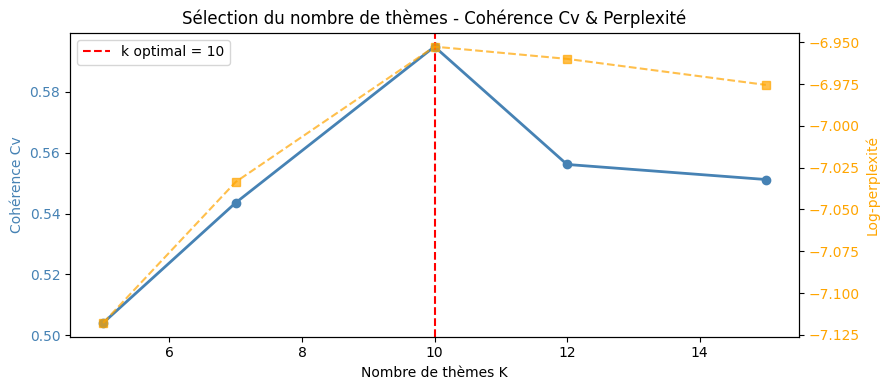

In [7]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(K_RANGE, coherence_scores, "o-", color="steelblue", lw=2)
ax1.axvline(best_k, color="red", linestyle="--", label=f"k optimal = {best_k}")
ax1.set_xlabel("Nombre de thèmes K")
ax1.set_ylabel("Cohérence Cv", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(K_RANGE, perplexity_scores, "s--", color="orange", lw=1.5, alpha=0.7)
ax2.set_ylabel("Log-perplexité", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

ax1.set_title("Sélection du nombre de thèmes - Cohérence Cv & Perplexité")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_lda_coherence.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 Modèle LDA final et interprétation des thèmes

On entraîne le modèle final avec k = best_k et 20 passes pour la convergence. La lecture des top mots révèle les structures thématiques - **les labels sont à compléter manuellement** après lecture des résultats.

In [8]:
lda_models_gensim = {}
lda_final = LdaModel(
    corpus=corpus_bow, id2word=dictionary,
    num_topics=best_k, passes=20,
    alpha="auto", eta="auto",
    random_state=42, eval_every=None
)
lda_models_gensim[best_k] = lda_final

cv_final = CoherenceModel(
    model=lda_final, texts=processed_texts,
    dictionary=dictionary, coherence="c_v"
).get_coherence()
print(f"Cohérence Cv finale : {cv_final:.4f}")

# Normaliser les composantes -> probabilités P(mot | topic)
vocab_gensim = [dictionary[i] for i in range(len(dictionary))]
components_norm = np.zeros((best_k, len(dictionary)))
for k in range(best_k):
    topic_terms = dict(lda_final.get_topic_terms(k, topn=len(dictionary)))
    for word_id, prob in topic_terms.items():
        components_norm[k, word_id] = prob

print("-" * 70)
for i in range(best_k):
    top = [dictionary[j] for j in components_norm[i].argsort()[:-16:-1]]
    print(f"Thème {i:2d} : {' | '.join(top)}")
print("-" * 70)

Cohérence Cv finale : 0.5940
----------------------------------------------------------------------
Thème  0 : confiance | homme | national | ensemble | électeur | vouloir | avenir | avoir | majorité | assemblée | falloir | progrès | vie | valeur | enfant
Thème  1 : travailleur | entreprise | payer | patron | maintenir | patronat | devoir | falloir | jeter | année | vendre | salaire | sacrifice | homme | dire
Thème  2 : écologie | entente | ecologiste | écologiste | vert | vie | environnement | ecologie | assemblée | humain | generation | chance | génération | homme | monde
Thème  3 : travailleur | ouvrier | non | public | école | salaire | milliard | unité | droit | guerre | gouvernement | vouloir | million | peuple | contre
Thème  4 : nature | animal | nom | bulletin | existence | homme | activité | ecologiste | chasse | adresse | comporter | vote | massacre | risque | abus
Thème  5 : communiste | vote | force | contre | vouloir | défendre | progrès | falloir | entendre | avoir | neu

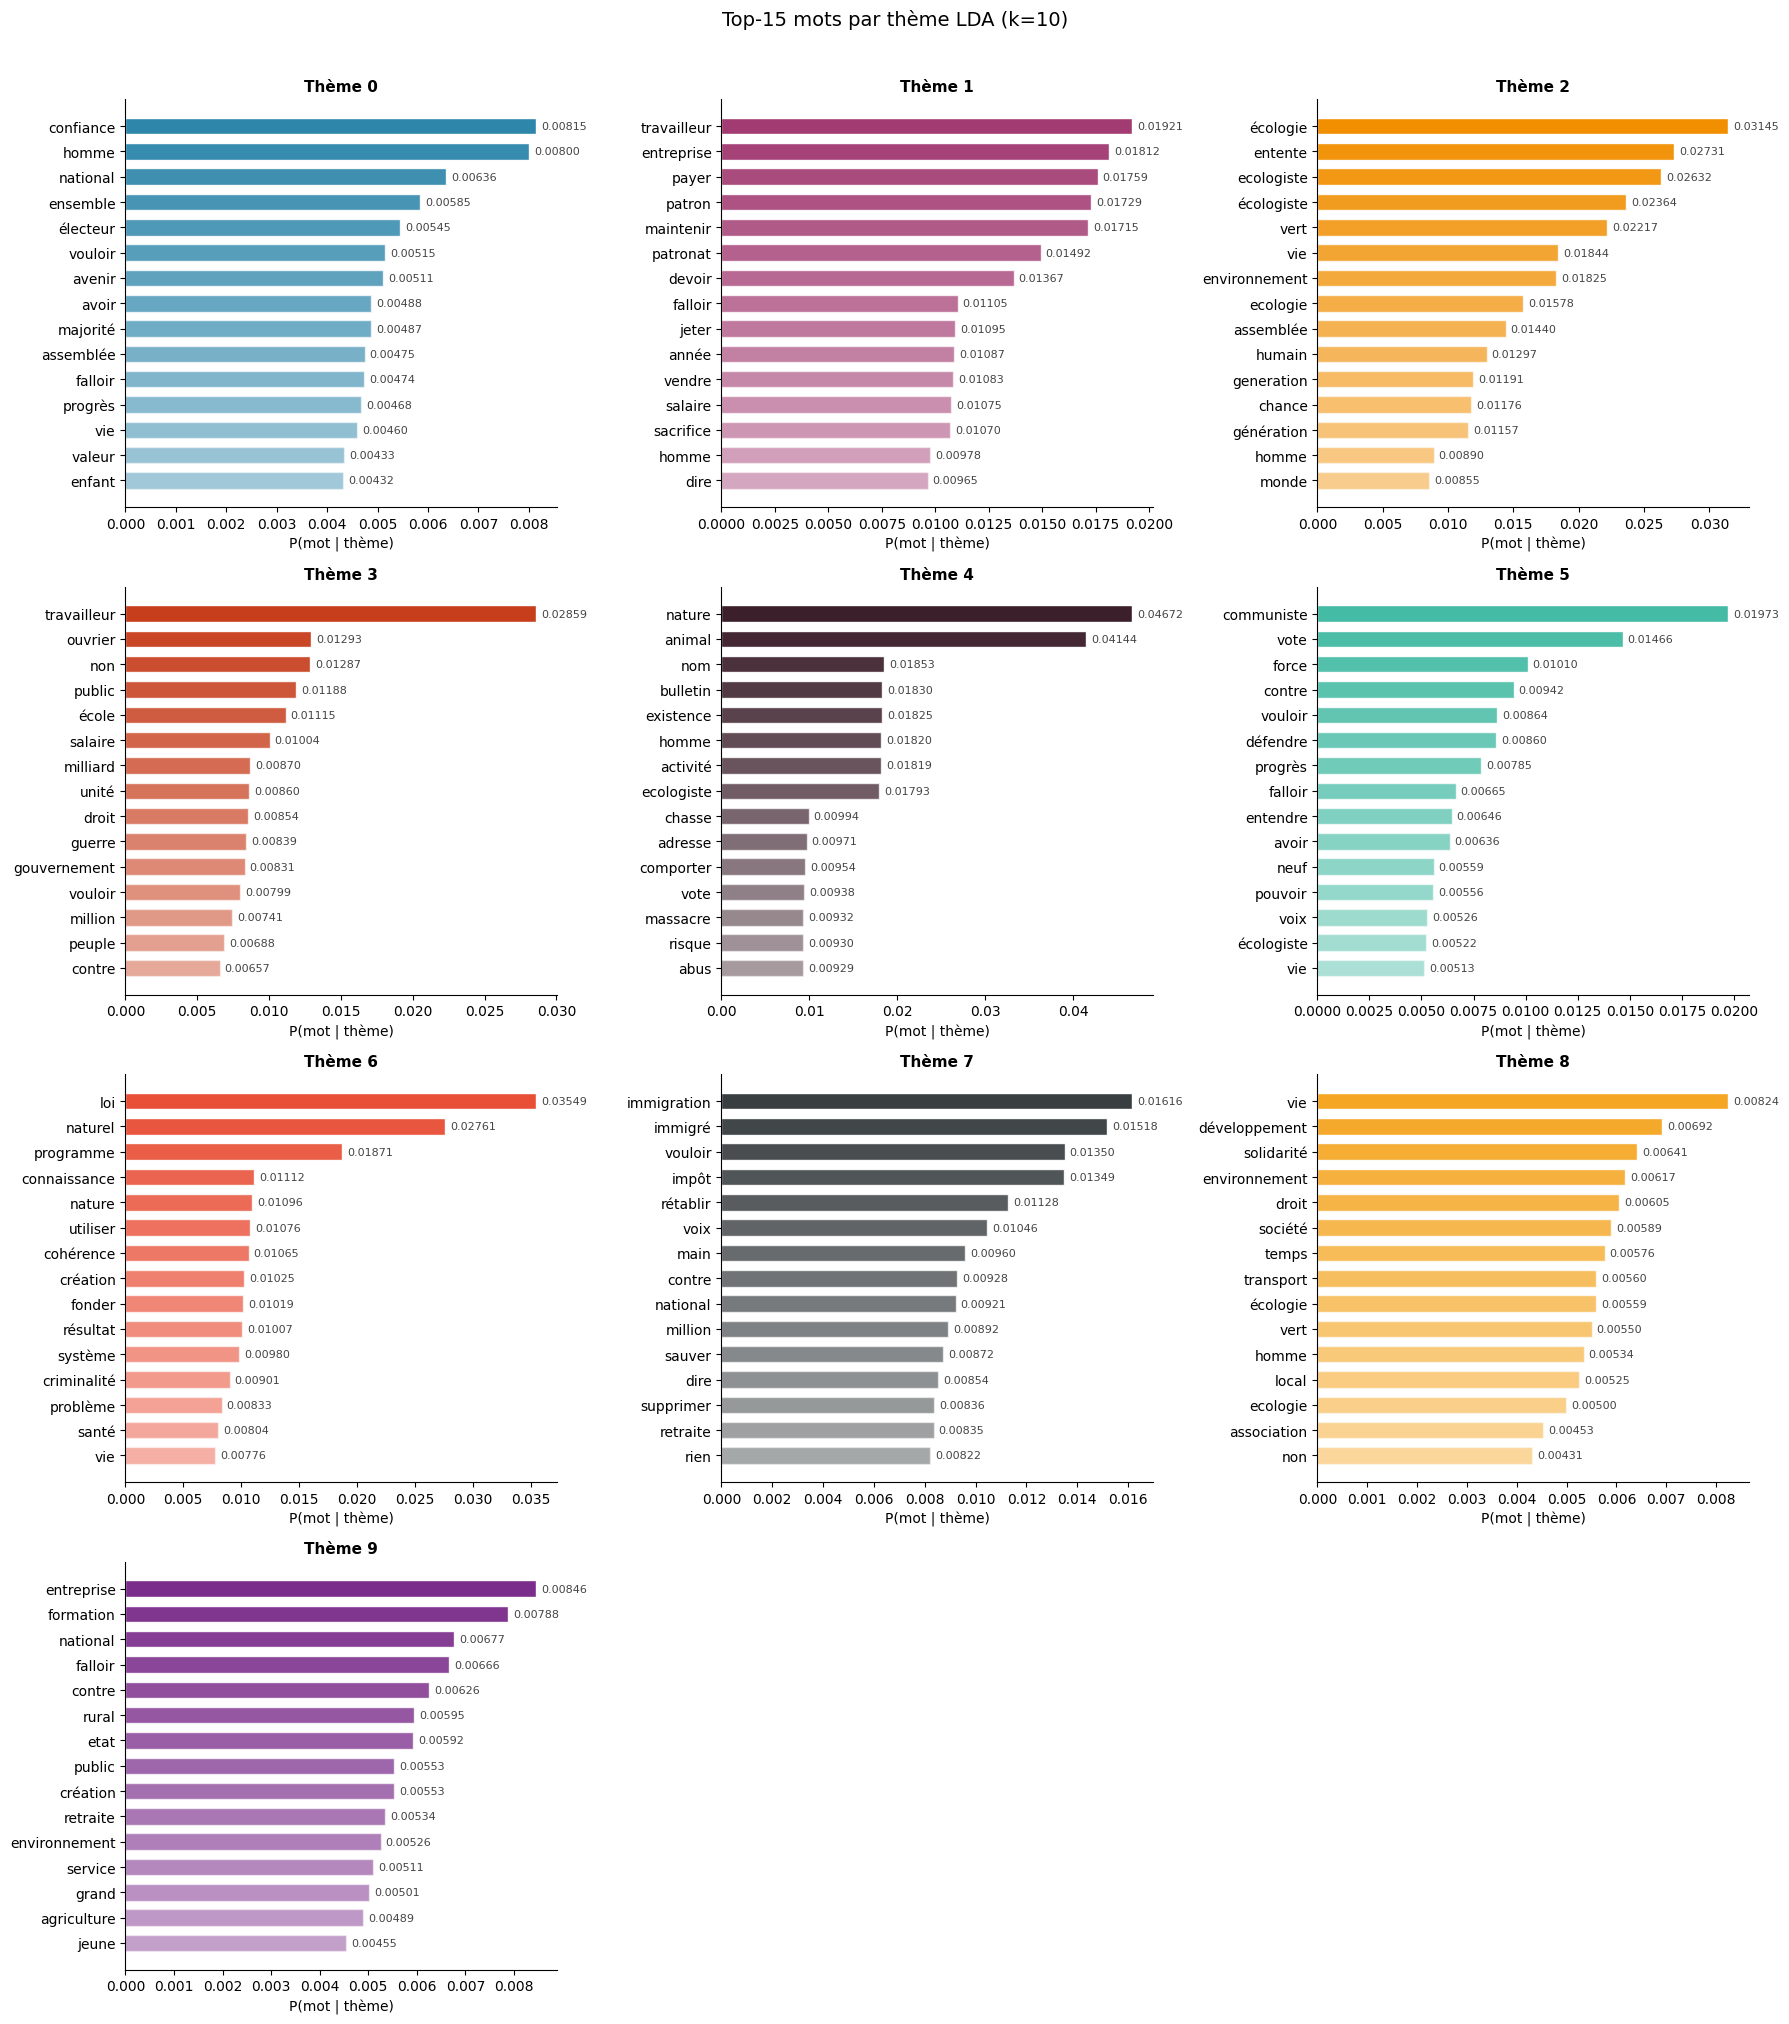

Sauvegarde OK.


In [9]:
# Visualisation top-15 mots par thème
PALETTE = [
    '#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B',
    '#44BBA4', '#E94F37', '#393E41', '#F5A623', '#7B2D8B',
    '#1B998B', '#E84855', '#3A86FF', '#FF006E', '#8338EC'
]

fig, axes = plt.subplots((best_k + 2) // 3, 3, figsize=(18, (best_k + 2) // 3 * 5))
axes = axes.flatten()

for topic_id in range(best_k):
    ax    = axes[topic_id]
    top15 = sorted(dict(lda_final.get_topic_terms(topic_id, topn=15)).items(), key=lambda x: x[1])
    mots  = [dictionary[wid] for wid, _ in top15]
    probs = [p for _, p in top15]
    alphas = np.linspace(0.45, 1.0, len(mots))
    color = PALETTE[topic_id % len(PALETTE)]
    for i, (mot, val) in enumerate(zip(mots, probs)):
        ax.barh(mot, val, color=color, alpha=alphas[i], edgecolor='white', height=0.65)
        ax.text(val + max(probs) * 0.012, i, f'{val:.5f}',
                va='center', ha='left', fontsize=8, color='#444444')
    ax.set_title(f"Thème {topic_id}", fontsize=11, fontweight="bold")
    ax.set_xlabel("P(mot | thème)")
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[best_k:]:
    ax.set_visible(False)

plt.suptitle(f"Top-15 mots par thème LDA (k={best_k})", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_lda_topic_words.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegarde OK.")

In [10]:
# --------------------------------------─
# LABELS INTERPRÉTATIFS - À COMPLÉTER manuellement après lecture des top mots
# --------------------------------------─

TOPIC_LABELS = {
    0: "Discours institutionnel et valeurs républicaines",
    1: "Rapports sociaux et critique du patronat",
    2: "Écologie politique (Verts / GE)",
    3: "Services publics et monde ouvrier",
    4: "Protection animale, nature et anti-chasse",
    5: "Mobilisation électorale communiste",
    6: "Parti de la Loi Naturelle (maharishi védique)",
    7: "Immigration et fiscalité",
    8: "Action locale, solidarité et politiques territoriales",
    9: "Ruralité, agriculture et développement territorial",
}


for k in range(len(TOPIC_LABELS), best_k):
    TOPIC_LABELS[k] = f"Thème {k} - à compléter"

print("Labels définis :")
for k, v in TOPIC_LABELS.items():
    top3 = [dictionary[j] for j in components_norm[k].argsort()[:-4:-1]]
    print(f"  [{k:2d}] {v:<45} : {', '.join(top3)}")

Labels définis :
  [ 0] Discours institutionnel et valeurs républicaines : confiance, homme, national
  [ 1] Rapports sociaux et critique du patronat      : travailleur, entreprise, payer
  [ 2] Écologie politique (Verts / GE)               : écologie, entente, ecologiste
  [ 3] Services publics et monde ouvrier             : travailleur, ouvrier, non
  [ 4] Protection animale, nature et anti-chasse     : nature, animal, nom
  [ 5] Mobilisation électorale communiste            : communiste, vote, force
  [ 6] Parti de la Loi Naturelle (maharishi védique) : loi, naturel, programme
  [ 7] Immigration et fiscalité                      : immigration, immigré, vouloir
  [ 8] Action locale, solidarité et politiques territoriales : vie, développement, solidarité
  [ 9] Ruralité, agriculture et développement territorial : entreprise, formation, national


### 2.4 Distribution des thèmes par document

In [11]:
# Inférence : distribution thèmes pour chaque doc (vecteur θ_d)
theta = np.zeros((len(corpus_bow), best_k))
for i, bow in enumerate(corpus_bow):
    for topic_id, prob in lda_final.get_document_topics(bow, minimum_probability=0.0):
        theta[i, topic_id] = prob

df["lda_dominant_topic"] = theta.argmax(axis=1)
df["lda_dominant_label"] = df["lda_dominant_topic"].map(TOPIC_LABELS)

for k in range(best_k):
    df[f"lda_topic_{k}"] = theta[:, k]

print("Distribution du thème dominant :")
print(df["lda_dominant_label"].value_counts().to_string())

Distribution du thème dominant :
lda_dominant_label
Discours institutionnel et valeurs républicaines         1736
Ruralité, agriculture et développement territorial        977
Mobilisation électorale communiste                        607
Immigration et fiscalité                                  584
Action locale, solidarité et politiques territoriales     473
Protection animale, nature et anti-chasse                 466
Écologie politique (Verts / GE)                           393
Rapports sociaux et critique du patronat                  235
Services publics et monde ouvrier                         131
Parti de la Loi Naturelle (maharishi védique)              96


### 2.5 Visualisation interactive (pyLDAvis)

pyLDAvis permet d'explorer les thèmes LDA : chaque bulle = un thème, sa taille est proportionnelle à son poids global. En sélectionnant une bulle, on voit les termes les plus représentatifs (λ=1) ou les plus exclusifs (λ=0).
Fichier HTML sauvegardé pour exploration hors notebook.

In [12]:
import pyLDAvis
import pyLDAvis.gensim_models

pyLDAvis.enable_notebook()
vis = pyLDAvis.gensim_models.prepare(
    lda_final, corpus_bow, dictionary,
    mds="mmds",       # plus stable que tsne sur grands corpus
    sort_topics=False
)
pyLDAvis.save_html(vis, str(FIGURES_DIR / "02_lda_vis.html"))
print("Sauvegardé :", FIGURES_DIR / "02_lda_vis.html")
pyLDAvis.display(vis)

Sauvegardé : ../figures/02_lda_vis.html


### 2.6 Spécialisation thématique par parti

Pour chaque famille partisane, on calcule :
1. La **distribution moyenne** des thèmes (poids θ moyen)
2. Un **log-ratio de spécialisation** :  spec(p,k) = log(θ̄_pk / θ̄_k)
Un score positif signale une sur-représentation du thème k dans le parti p.

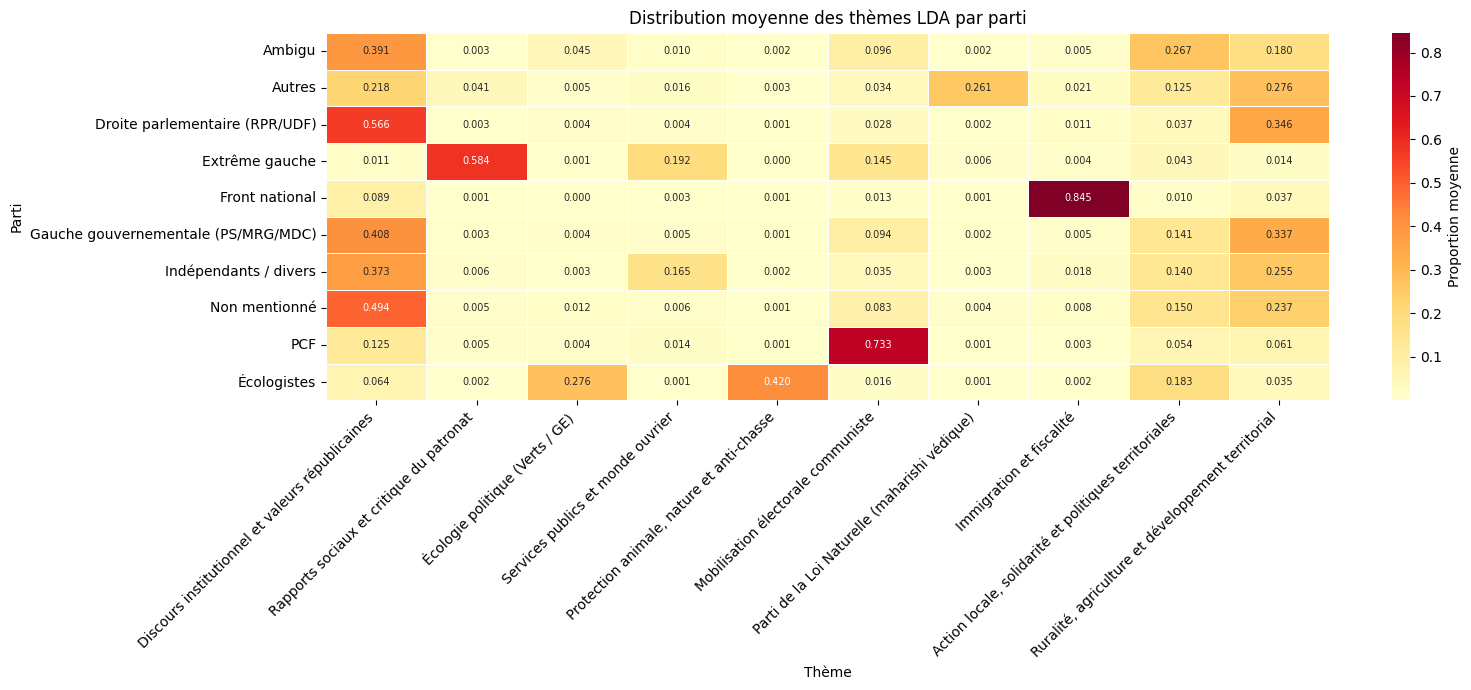

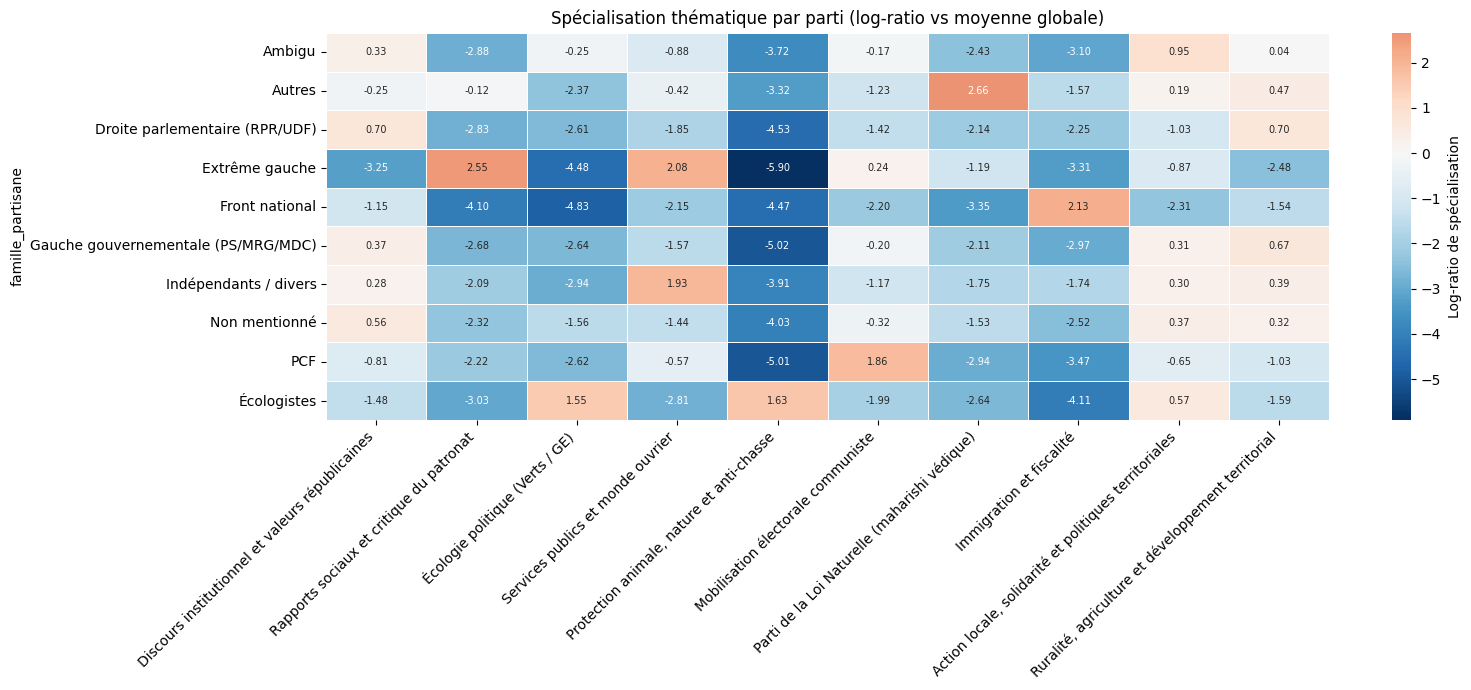


Thème le plus sur-représenté par parti (log-ratio maximal) :
  Ambigu                                   -> Action locale, solidarité et politi (0.95)
  Autres                                   -> Parti de la Loi Naturelle (maharish (2.66)
  Droite parlementaire (RPR/UDF)           -> Discours institutionnel et valeurs  (0.70)
  Extrême gauche                           -> Rapports sociaux et critique du pat (2.55)
  Front national                           -> Immigration et fiscalité (2.13)
  Gauche gouvernementale (PS/MRG/MDC)      -> Ruralité, agriculture et développem (0.67)
  Indépendants / divers                    -> Services publics et monde ouvrier (1.93)
  Non mentionné                            -> Discours institutionnel et valeurs  (0.56)
  PCF                                      -> Mobilisation électorale communiste (1.86)
  Écologistes                              -> Protection animale, nature et anti- (1.63)


In [13]:
topic_cols  = [f"lda_topic_{i}" for i in range(best_k)]
labels_list = [TOPIC_LABELS[i] for i in range(best_k)]

parti_topic = (
    df.groupby("famille_partisane", observed=True)[topic_cols].mean()
    .rename(columns={f"lda_topic_{i}": TOPIC_LABELS[i] for i in range(best_k)})
)

# - Heatmap distribution moyenne -
fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(parti_topic, cmap="YlOrRd", ax=ax, linewidths=0.4,
            cbar_kws={"label": "Proportion moyenne"}, fmt=".3f", annot=True,
            annot_kws={"fontsize": 7})
ax.set_title("Distribution moyenne des thèmes LDA par parti")
ax.set_xlabel("Thème"); ax.set_ylabel("Parti")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_lda_topic_by_parti.png", dpi=150, bbox_inches="tight")
plt.show()

# - Log-ratio de spécialisation -
global_dist = df[topic_cols].mean().values
eps = 1e-6
log_ratio_mat = np.log((parti_topic.values + eps) / (global_dist + eps))
df_logratio   = pd.DataFrame(log_ratio_mat, index=parti_topic.index, columns=labels_list)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(df_logratio, cmap="RdBu_r", center=0, ax=ax, linewidths=0.4,
            cbar_kws={"label": "Log-ratio de spécialisation"},
            fmt=".2f", annot=True, annot_kws={"fontsize": 7})
ax.set_title("Spécialisation thématique par parti (log-ratio vs moyenne globale)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_lda_specialisation.png", dpi=150, bbox_inches="tight")
plt.show()

# - Topic signature par parti -
print("\nThème le plus sur-représenté par parti (log-ratio maximal) :")
print("=" * 65)
for parti in df_logratio.index:
    top = df_logratio.loc[parti].idxmax()
    score = df_logratio.loc[parti].max()
    print(f"  {parti:<40} -> {top[:35]} ({score:.2f})")

## 3. NMF (Non-negative Matrix Factorization)

La NMF est la seconde approche bag-of-words présentée en cours. Elle factorise la matrice TF-IDF V en deux matrices non-négatives : W (poids des themes par document) et H (motspar theme). Comparée à la LDA, la NMF tend a produire des themes plus nets.

### 3.1 Vectorisation TF-IDF

### 3.2 Modele NMF et interpretation des themes

In [14]:
# Labels NMF etablis apres lecture des top mots

TOPIC_LABELS_NMF = {
    0: "Protection animale et écologie militante locale",
    1: "Immigration et fiscalité",
    2: "Développement local, ruralité et avenir économique",
    3: "Discours ouvrier et critique du patronat",
    4: "Écologie politique institutionnelle (Verts / GE)",
    5: "Parti de la Loi Naturelle (maharishi védique)",
    6: "Mobilisation électorale communiste",
    7: "Souveraineté de l'État et restauration de la puissance publique",
    8: "Gauche contestataire, pacifisme et services publics",
    9: "Crise sociale, quotidien et discours du changement",
}

print('Topics NMF K= 10 -- labels definitifs :')
print('-' * 70)
for tid, label in TOPIC_LABELS_NMF.items():
    top5 = [vocab_tfidf[j] for j in H_nmf[tid].argsort()[:-6:-1]]
    print(f'  [{tid:2d}] {label:<45} : {", ".join(top5)}')

Topics NMF K= 10 -- labels definitifs :
----------------------------------------------------------------------
  [ 0] Protection animale et écologie militante locale : animal, nature animal, nature, ecologiste nature, nouveau ecologiste
  [ 1] Immigration et fiscalité                      : immigré, immigration, rétablir, impôt, carte
  [ 2] Développement local, ruralité et avenir économique : vie, confiance, ensemble, progrès, développement
  [ 3] Discours ouvrier et critique du patronat      : patron, payer, patronat, travailleur, maintenir
  [ 4] Écologie politique institutionnelle (Verts / GE) : écologie, entente, entente ecologiste, ecologiste, vert
  [ 5] Parti de la Loi Naturelle (maharishi védique) : loi naturel, loi, naturel, cohérence, loi nature
  [ 6] Mobilisation électorale communiste            : communiste, vote communiste, vote, neuf, dirigeant
  [ 7] Souveraineté de l'État et restauration de la puissance publique : alliance populaire, instauration, maintien, humiliatio

### 3.3 Specialisation partisane NMF

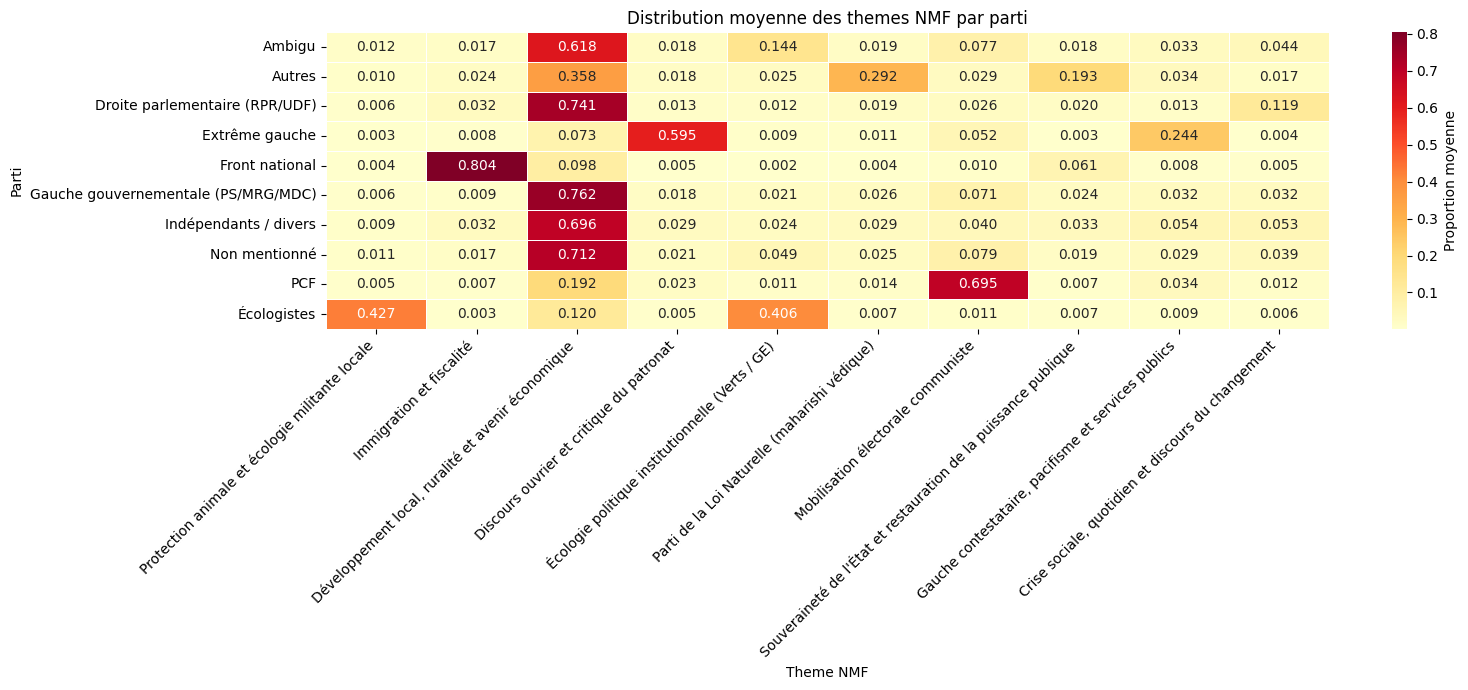

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
W_nmf_norm = W_nmf / (W_nmf.sum(axis=1, keepdims=True) + 1e-9)

for i in range(best_k):
    df[f'nmf_topic_{i}'] = W_nmf_norm[:, i]

nmf_cols = [f'nmf_topic_{i}' for i in range(best_k)]

parti_nmf = (
    df.groupby('famille_partisane', observed=True)[nmf_cols].mean()
    .rename(columns={f'nmf_topic_{i}': TOPIC_LABELS_NMF[i] for i in range(best_k)})
)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(parti_nmf, cmap='YlOrRd', ax=ax, linewidths=0.4,
            cbar_kws={'label': 'Proportion moyenne'}, fmt='.3f', annot=True)
ax.set_title('Distribution moyenne des themes NMF par parti')
ax.set_xlabel('Theme NMF'); ax.set_ylabel('Parti')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_nmf_topic_by_parti.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. BERTopic

BERTopic encode chaque document dans un espace semantique de 384 dimensions via le modele BERT multilingue paraphrase-multilingual-MiniLM-L12-v2 (Reimers & Gurevych, 2019). Ces embeddings contextuels capturent le sens des mots en fonction de leur contexte, ce que les approches bag-of-words ne peuvent pas faire.

Le pipeline : embeddings (SentenceTransformer) -> reduction dimensionnelle (UMAP, 5D,
metrique cosinus) -> clustering (HDBSCAN) -> representation des themes (TF-IDF par classe).

> Problème : Le service Onyxia utilisé a bien un GPU, mais la version PyTorch installée n'est pas compatible avec le driver NVIDIA disponible. Nous utilisons donc device="cpu". 
>Nous nous abstenons donc d'utiliser d'autres modèles d'embedding lourds (comme Camembert par exemple) pour ne pas avoir des codes qui tournent sur un temps trop longs. 

### 4.1 Chargement des embeddings (mis en cache)

In [16]:
EMB_FILE = PROC_DIR / 'embeddings_1993.npy'

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device détecté :", device)

try:
    embedding_model = SentenceTransformer(
        "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        device=device
    )
except RuntimeError as e:
    print("CUDA indisponible ou incompatible. Passage en CPU.")
    embedding_model = SentenceTransformer(
        "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
        device="cpu"
    )

docs_for_bert = df["clean_text_embeddings"].tolist()

embeddings = embedding_model.encode(
    docs_for_bert,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

np.save(EMB_FILE, embeddings)

print("Embeddings :", embeddings.shape)
print("Sauvegardé dans :", EMB_FILE)

Device détecté : cpu


Batches: 100%|██████████| 179/179 [04:06<00:00,  1.38s/it]

Embeddings : (5698, 384)
Sauvegardé dans : ../data/processed/embeddings_1993.npy


In [17]:
assert len(docs_for_bert) == embeddings.shape[0]

In [18]:
assert len(df) == embeddings.shape[0]

### 4.2 Pipeline BERTopic

In [19]:
df['bert_text_final'] = df['clean_text_embeddings']
df['n_words_bert'] = df['bert_text_final'].str.split().str.len()
df_bert = df[df['n_words_bert'] >= 50].copy()
docs_for_bert = df_bert['bert_text_final'].tolist()
embeddings_bert = embeddings[df_bert.index]


In [20]:
nlp = spacy.load("fr_core_news_md")

stop_words_fr = list(nlp.Defaults.stop_words.union(EXTRA_STOPS))

docs_for_bert = df_bert["bert_text_final"].tolist()

vectorizer_bt = CountVectorizer(
    stop_words=stop_words_fr,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.60,
    strip_accents=None,
    lowercase=True
)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=60,
    min_samples=8,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_bt,
    min_topic_size=60,
    calculate_probabilities=False,
    verbose=True
)

assert len(docs_for_bert) == embeddings_bert.shape[0]

topics, probs = topic_model.fit_transform(docs_for_bert, embeddings_bert)

topic_info = topic_model.get_topic_info()
topic_info

2026-04-30 16:59:37,694 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-30 17:00:11,988 - BERTopic - Dimensionality - Completed ✓
2026-04-30 17:00:11,992 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-30 17:00:12,164 - BERTopic - Cluster - Completed ✓
2026-04-30 17:00:12,169 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-30 17:00:15,516 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,156,-1_unit_cole_animaux_ouvrire,"[unit, cole, animaux, ouvrire, nom, publique, ...",[ELECTIONS LEGISLATIVES SCRUTIN DU MARS PARTI ...
1,0,4042,0_franais_nationale_dput_emploi,"[franais, nationale, dput, emploi, immigration...",[ELECTIONS LEGISLATIVES DE MARS 2ªme CIRCONSCR...
2,1,792,1_cologie_ecologistes_ecologie_vie,"[cologie, ecologistes, ecologie, vie, assemble...",[ELECTIONS LEGISLATIVES CIRCONSCRIPTION DE CHA...
3,2,242,2_animaux_nature animaux_complte_existence,"[animaux, nature animaux, complte, existence, ...",[RÉPUBLIQUE FRANÇAISE ÉLECTIONS LÉGISLATIVES D...
4,3,113,3_patrons_maintenir_patronat_maintenir emplois,"[patrons, maintenir, patronat, maintenir emplo...",[Elections législatives du mars Pourquoi voter...
5,4,97,4_loi_systme_lois_rsultats,"[loi, systme, lois, rsultats, problmes, scient...",[ELECTIONS LEGISLATIVES MARS Votre candidat du...
6,5,71,5_animaux_nature animaux_ecologistes nature_co...,"[animaux, nature animaux, ecologistes nature, ...",[RÉPUBLIQUE FRANÇAISE ÉLECTIONS LÉGISLATIVES D...
7,6,63,6_patrons_maintenir_patronat_maintenir emplois,"[patrons, maintenir, patronat, maintenir emplo...",[Elections législatives du mars Pourquoi voter...
8,7,61,7_patrons_maintenir_patronat_maintenir emplois,"[patrons, maintenir, patronat, maintenir emplo...",[Elections législatives du mars Pourquoi voter...
9,8,61,8_refus_maintien_mise_place,"[refus, maintien, mise, place, dfense, formati...",[alliance populaire CANDIDAT DE RASSEMBLEMENT ...


### 4.3 Distribution des themes BERTopic par parti

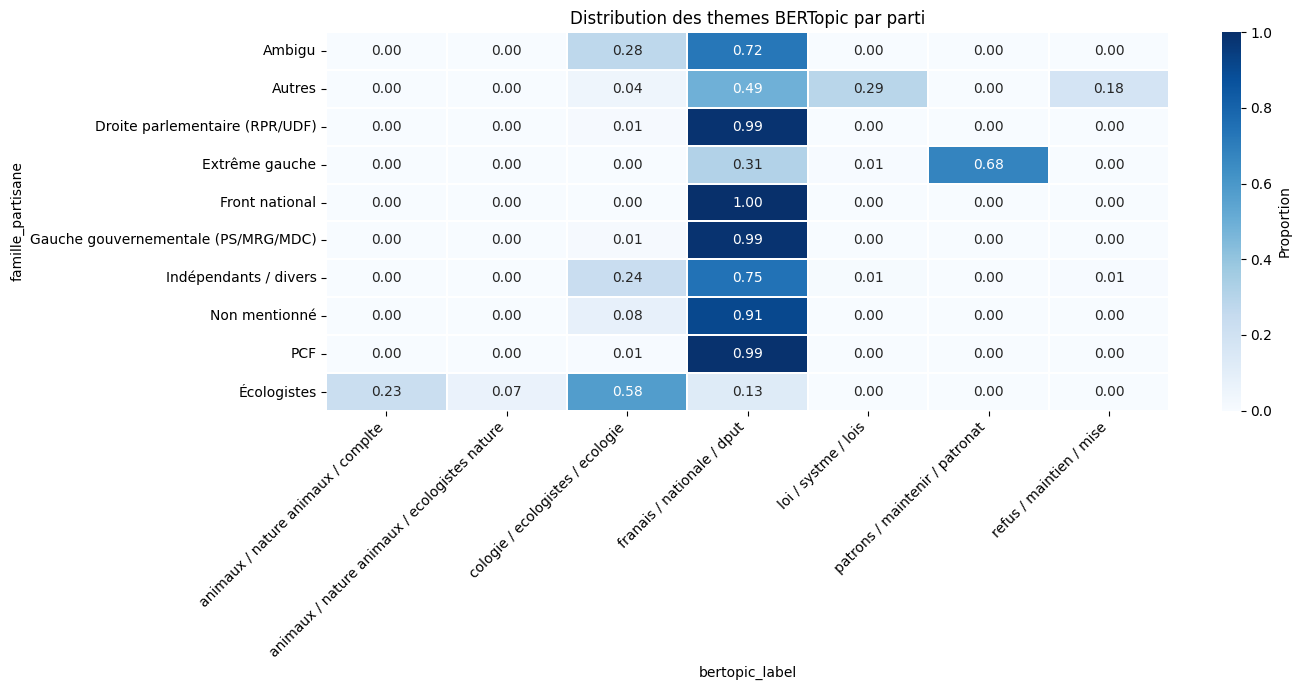

In [21]:
df['bertopic'] = -1
df.loc[df_bert.index, 'bertopic'] = topics


bt_names = {
    row['Topic']: ' / '.join(row['Representation'][:3])
    for _, row in topic_model.get_topic_info().iterrows() if row['Topic'] != -1
}
df['bertopic_label'] = df['bertopic'].map(bt_names).fillna('bruit')

df_bt = df[df['bertopic'] != -1].copy()
bt_dist = df_bt.groupby(['famille_partisane', 'bertopic_label']).size().unstack(fill_value=0)
bt_dist_pct = bt_dist.div(bt_dist.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(bt_dist_pct, cmap='Blues', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Proportion'}, fmt='.2f', annot=True)
ax.set_title('Distribution des themes BERTopic par parti')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_bertopic_by_parti.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Synthese comparative
Les 3 modèles présentent des niveaux de clareté et de cohérence différents. Le lda semble plus propre.

In [22]:
print('Recapitulatif final')
print('-' * 55)
print(f'LDA  : K={best_k}, Cv={max(coherence_scores):.4f}')
print(f'NMF  : K={best_k}, erreur reconstruction = {nmf_model.reconstruction_err_:.2f}')
print(f'BERT : {len(topic_info)-1} clusters, {(np.array(topics)==-1).sum()} docs non classes')
print('-' * 55)

Recapitulatif final
-------------------------------------------------------
LDA  : K=10, Cv=0.5949
NMF  : K=10, erreur reconstruction = 62.77
BERT : 9 clusters, 156 docs non classes
-------------------------------------------------------


## 6. Sauvegarde

In [23]:
COLS_OUT = (
    ['id', 'famille_partisane', 'titulaire-sexe',
     'lda_dominant_topic', 'lda_dominant_label', 'bertopic', 'bertopic_label']
    + [f'lda_topic_{i}' for i in range(best_k)]
    + [f'nmf_topic_{i}' for i in range(best_k)]
)

df[COLS_OUT].to_csv(PROC_DIR / 'topics_1993.csv', index=False)
print('Sauvegarde :', PROC_DIR / 'topics_1993.csv')

topic_model.save(str(PROC_DIR / 'bertopic_model_1993'))
print('Modele BERTopic sauvegarde.')

2026-04-30 17:00:17,185 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


Sauvegarde : ../data/processed/topics_1993.csv
Modele BERTopic sauvegarde.
